<img src="https://github.com/hernancontigiani/ceia_memorias_especializacion/raw/master/Figures/logoFIUBA.jpg" width="500" align="center">


# Procesamiento de lenguaje natural
# Desafio 4, LSTM Bot QA

### 1 - Datos
El objetivo es utilizar datos disponibles del challenge ConvAI2 (Conversational Intelligence Challenge 2) de conversaciones en inglés. Se construirá un BOT para responder a preguntas del usuario (QA).\
[LINK](http://convai.io/data/)

In [1]:
!pip install --upgrade --no-cache-dir gdown --quiet


[notice] A new release of pip is available: 26.0 -> 26.0.1
[notice] To update, run: pip install --upgrade pip


In [2]:
import re

import numpy as np
import pandas as pd

import tensorflow as tf
from tensorflow.keras.preprocessing.text import one_hot
from tensorflow.keras.utils import pad_sequences, plot_model
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Activation, Dropout, Dense
from tensorflow.keras.layers import Flatten, LSTM, SimpleRNN
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Embedding
from sklearn.model_selection import train_test_split
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.layers import Input

2026-04-22 22:20:25.475641: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


In [3]:
# Descargar la carpeta de dataset
import os
import gdown
if os.access('data_volunteers.json', os.F_OK) is False:
    url = 'https://drive.google.com/uc?id=1awUxYwImF84MIT5-jCaYAPe2QwSgS1hN&export=download'
    output = 'data_volunteers.json'
    gdown.download(url, output, quiet=False)
else:
    print("El dataset ya se encuentra descargado")

El dataset ya se encuentra descargado


In [4]:
# dataset_file
import json

text_file = "data_volunteers.json"
with open(text_file) as f:
    data = json.load(f) # la variable data será un diccionario



In [5]:
# Observar los campos disponibles en cada linea del dataset
data[0].keys()

dict_keys(['dialog', 'start_time', 'end_time', 'bot_profile', 'user_profile', 'eval_score', 'profile_match', 'participant1_id', 'participant2_id'])

In [6]:
chat_in = []
chat_out = []

input_sentences = []
output_sentences = []
output_sentences_inputs = []
max_len = 30

def clean_text(txt):
    txt = txt.lower()
    txt.replace("\'d", " had")
    txt.replace("\'s", " is")
    txt.replace("\'m", " am")
    txt.replace("don't", "do not")
    txt = re.sub(r'\W+', ' ', txt)

    return txt

for line in data:
    for i in range(len(line['dialog'])-1):
        # vamos separando el texto en "preguntas" (chat_in)
        # y "respuestas" (chat_out)
        chat_in = clean_text(line['dialog'][i]['text'])
        chat_out = clean_text(line['dialog'][i+1]['text'])

        if len(chat_in) >= max_len or len(chat_out) >= max_len:
            continue

        input_sentence, output = chat_in, chat_out

        # output sentence (decoder_output) tiene <eos>
        output_sentence = output + ' <eos>'
        # output sentence input (decoder_input) tiene <sos>
        output_sentence_input = '<sos> ' + output

        input_sentences.append(input_sentence)
        output_sentences.append(output_sentence)
        output_sentences_inputs.append(output_sentence_input)

print("Cantidad de rows utilizadas:", len(input_sentences))

Cantidad de rows utilizadas: 6033


In [7]:
input_sentences[1], output_sentences[1], output_sentences_inputs[1]

('hi how are you ', 'not bad and you  <eos>', '<sos> not bad and you ')

### ***Pueden realizar el desafio en Keras o PyTorch.***

### 2 - Preprocesamiento
Realizar el preprocesamiento necesario para obtener:
- word2idx_inputs, max_input_len
- word2idx_outputs, max_out_len, num_words_output
- encoder_input_sequences, decoder_output_sequences, decoder_targets

#### Tokenizador de las entradas

In [8]:
MAX_VOCAB_SIZE = 4000

input_tokenizer = Tokenizer(num_words=MAX_VOCAB_SIZE)
input_tokenizer.fit_on_texts(input_sentences)
input_integer_seq = input_tokenizer.texts_to_sequences(input_sentences)

word2idx_inputs = input_tokenizer.word_index
print("Palabras en el vocabulario:", len(word2idx_inputs))

max_input_len = max(len(sen) for sen in input_integer_seq)
print("Entrada más larga en palabras:", max_input_len)

Palabras en el vocabulario: 1799
Entrada más larga en palabras: 9


#### Tokenizador de las respuestas del bot

In [9]:
output_tokenizer = Tokenizer(num_words=MAX_VOCAB_SIZE, filters='!"#$%&()*+,-./:;=?@[\\]^_`{|}~\t\n')
output_tokenizer.fit_on_texts(["<sos>", "<eos>"] + output_sentences)
output_integer_seq = output_tokenizer.texts_to_sequences(output_sentences)
output_input_integer_seq = output_tokenizer.texts_to_sequences(output_sentences_inputs)

word2idx_outputs = output_tokenizer.word_index
print("Palabras en el vocabulario:", len(word2idx_outputs))

# Se suma 1 para incluir el token de palabra desconocida
num_words_output = min(len(word2idx_outputs) + 1, MAX_VOCAB_SIZE)

max_out_len = max(len(sen) for sen in output_integer_seq)
print("Respuesta más larga en palabras:", max_out_len)

Palabras en el vocabulario: 1806
Respuesta más larga en palabras: 10


In [10]:
print("Cantidad de rows del dataset:", len(input_integer_seq))

encoder_input_sequences = pad_sequences(input_integer_seq, maxlen=max_input_len)
print("encoder_input_sequences shape:", encoder_input_sequences.shape)

decoder_input_sequences = pad_sequences(output_input_integer_seq, maxlen=max_out_len, padding='post')
print("decoder_input_sequences shape:", decoder_input_sequences.shape)

Cantidad de rows del dataset: 6033


encoder_input_sequences shape: (6033, 9)
decoder_input_sequences shape: (6033, 10)


Afortunadamente tenemos un tamaño máximo de entradas relativamente chico y por ende no habrá inconvenientes con la RAM necesaria.

In [11]:
from tensorflow.keras.utils import to_categorical
decoder_output_sequences = pad_sequences(output_integer_seq, maxlen=max_out_len, padding='post')
decoder_targets = to_categorical(decoder_output_sequences, num_classes=num_words_output)
decoder_targets.shape

(6033, 10, 1807)

Mapeamos los diccionarios de índice a palabra.

In [12]:
idx2word_input = {v:k for k, v in word2idx_inputs.items()}
idx2word_target = {v:k for k, v in word2idx_outputs.items()}

### 3 - Preparar los embeddings
Utilizar los embeddings de Glove o FastText para transformar los tokens de entrada en vectores

#### Descarga de los pesos de Glove

In [13]:
import os
import gdown

def is_valid_pickle(path):
    try:
        with open(path, "rb") as f:
            head = f.read(20)
        # Si empieza con "<!DOCTYPE" o "<html", es HTML → inválido
        if b"<html" in head.lower() or b"<!doctype" in head.lower():
            return False
        return True
    except:
        return False

file_path = "gloveembedding.pkl"
file_id = "1KY6avD5I1eI2dxQzMkR3WExwKwRq2g94"

if not os.path.exists(file_path) or not is_valid_pickle(file_path):
    print("Descargando embeddings desde Google Drive...")

    # Borra archivo corrupto si existe
    if os.path.exists(file_path):
        os.remove(file_path)

    # Descarga correcta (maneja archivos grandes con confirm token)
    gdown.download(id=file_id, output=file_path, quiet=False)

    # Validación post-descarga
    if not is_valid_pickle(file_path):
        raise ValueError("❌ El archivo descargado no es un pickle válido (probablemente HTML de Drive).")

    print("✅ Descarga completada correctamente")

else:
    print("✅ Los embeddings ya están descargados y son válidos")

✅ Los embeddings ya están descargados y son válidos


#### Herramienta para cargar y guardar el modelo

In [14]:
import logging
import os
from pathlib import Path
import pickle

class WordsEmbeddings(object):
    logger = logging.getLogger(__name__)

    def __init__(self):
        # load the embeddings
        words_embedding_pkl = Path(self.PKL_PATH)
        if not words_embedding_pkl.is_file():
            words_embedding_txt = Path(self.WORD_TO_VEC_MODEL_TXT_PATH)
            assert words_embedding_txt.is_file(), 'Words embedding not available'
            embeddings = self.convert_model_to_pickle()
        else:
            embeddings = self.load_model_from_pickle()
        self.embeddings = embeddings
        # build the vocabulary hashmap
        index = np.arange(self.embeddings.shape[0])
        # Dicctionarios para traducir de embedding a IDX de la palabra
        self.word2idx = dict(zip(self.embeddings['word'], index))
        self.idx2word = dict(zip(index, self.embeddings['word']))

    def get_words_embeddings(self, words):
        words_idxs = self.words2idxs(words)
        return self.embeddings[words_idxs]['embedding']

    def words2idxs(self, words):
        return np.array([self.word2idx.get(word, -1) for word in words])

    def idxs2words(self, idxs):
        return np.array([self.idx2word.get(idx, '-1') for idx in idxs])

    def load_model_from_pickle(self):
        self.logger.debug(
            'loading words embeddings from pickle {}'.format(
                self.PKL_PATH
            )
        )
        max_bytes = 2**28 - 1 # 256MB
        bytes_in = bytearray(0)
        input_size = os.path.getsize(self.PKL_PATH)
        with open(self.PKL_PATH, 'rb') as f_in:
            for _ in range(0, input_size, max_bytes):
                bytes_in += f_in.read(max_bytes)
        embeddings = pickle.loads(bytes_in)
        self.logger.debug('words embeddings loaded')
        return embeddings

    def convert_model_to_pickle(self):
        # create a numpy strctured array:
        # word     embedding
        # U50      np.float32[]
        # word_1   a, b, c
        # word_2   d, e, f
        # ...
        # word_n   g, h, i
        self.logger.debug(
            'converting and loading words embeddings from text file {}'.format(
                self.WORD_TO_VEC_MODEL_TXT_PATH
            )
        )
        structure = [('word', np.dtype('U' + str(self.WORD_MAX_SIZE))),
                     ('embedding', np.float32, (self.N_FEATURES,))]
        structure = np.dtype(structure)
        # load numpy array from disk using a generator
        with open(self.WORD_TO_VEC_MODEL_TXT_PATH, encoding="utf8") as words_embeddings_txt:
            embeddings_gen = (
                (line.split()[0], line.split()[1:]) for line in words_embeddings_txt
                if len(line.split()[1:]) == self.N_FEATURES
            )
            embeddings = np.fromiter(embeddings_gen, structure)
        # add a null embedding
        null_embedding = np.array(
            [('null_embedding', np.zeros((self.N_FEATURES,), dtype=np.float32))],
            dtype=structure
        )
        embeddings = np.concatenate([embeddings, null_embedding])
        # dump numpy array to disk using pickle
        max_bytes = 2**28 - 1 # # 256MB
        bytes_out = pickle.dumps(embeddings, protocol=pickle.HIGHEST_PROTOCOL)
        with open(self.PKL_PATH, 'wb') as f_out:
            for idx in range(0, len(bytes_out), max_bytes):
                f_out.write(bytes_out[idx:idx+max_bytes])
        self.logger.debug('words embeddings loaded')
        return embeddings


class GloveEmbeddings(WordsEmbeddings):
    WORD_TO_VEC_MODEL_TXT_PATH = 'glove.twitter.27B.50d.txt'
    PKL_PATH = 'gloveembedding.pkl'
    N_FEATURES = 50
    WORD_MAX_SIZE = 60

class FasttextEmbeddings(WordsEmbeddings):
    WORD_TO_VEC_MODEL_TXT_PATH = 'cc.en.300.vec'
    PKL_PATH = 'fasttext.pkl'
    N_FEATURES = 300
    WORD_MAX_SIZE = 60

In [15]:
model_embeddings = GloveEmbeddings()

#### Embedding matrix de las entradas y el vocabulario

In [16]:
print('preparing embedding matrix...')
embed_dim = model_embeddings.N_FEATURES
words_not_found = []

nb_words = min(MAX_VOCAB_SIZE, len(word2idx_inputs) + 1) # vocab_size
embedding_matrix = np.zeros((nb_words, embed_dim))
for word, i in word2idx_inputs.items():
    if i >= nb_words:
        continue
    embedding_vector = model_embeddings.get_words_embeddings(word)[0]
    if (embedding_vector is not None) and len(embedding_vector) > 0:

        embedding_matrix[i] = embedding_vector
    else:
        # words not found in embedding index will be all-zeros.
        words_not_found.append(word)

print('number of null word embeddings:', np.sum(np.sum(embedding_matrix**2, axis=1) == 0))

preparing embedding matrix...
number of null word embeddings: 38


In [17]:
print('Dimensión de los embeddings de las entradas:',embedding_matrix.shape)

Dimensión de los embeddings de las entradas: (1800, 50)


### 4 - Entrenar el modelo
Entrenar un modelo basado en el esquema encoder-decoder utilizando los datos generados en los puntos anteriores. Utilce como referencias los ejemplos vistos en clase.

#### Armamos el modelo encoder y decoder de entrenamiento
Cargamos los pesos Glove en la capa de embeddings.

In [18]:
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, LSTM, Dense

n_units = 128

encoder_inputs = Input(shape=(max_input_len,))

encoder_embedding_layer = Embedding(
          input_dim=nb_words,  # definido en el Tokenizador
          output_dim=embed_dim,  # dimensión de los embeddings utilizados
          input_length=max_input_len, # tamaño máximo de la secuencia de entrada
          trainable=False)      # marcar como layer no entrenable

# El parametro weights se encuentra deprecado. Se setea el peso después de la creación de la capa.
encoder_embedding_layer.build((None, max_input_len))
encoder_embedding_layer.set_weights([embedding_matrix])

encoder_inputs_x = encoder_embedding_layer(encoder_inputs)

encoder = LSTM(n_units, return_state=True)
encoder_outputs, state_h, state_c = encoder(encoder_inputs_x)
encoder_states = [state_h, state_c]

# define training decoder
decoder_inputs = Input(shape=(max_out_len,))
decoder_embedding_layer = Embedding(input_dim=num_words_output, output_dim=n_units, input_length=max_out_len)
decoder_inputs_x = decoder_embedding_layer(decoder_inputs)

decoder_lstm = LSTM(n_units, return_sequences=True, return_state=True)
decoder_outputs, _, _ = decoder_lstm(decoder_inputs_x, initial_state=encoder_states)

# Dense
decoder_dense = Dense(num_words_output, activation='softmax')
decoder_outputs = decoder_dense(decoder_outputs)
model = Model([encoder_inputs, decoder_inputs], decoder_outputs)

model.compile(loss='categorical_crossentropy', optimizer="Adam", metrics=['accuracy'])
model.summary()

/Users/umagon/Documents/Facultad/Especializacion en IA/NLP/nlp_desafios/.venv/lib/python3.12/site-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 9)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ input_layer_1       │ (None, 10)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding           │ (None, 9, 50)     │     90,000 │ input_layer[0][0] │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding_1         │ (None, 10, 128)   │    231,296 │ input_layer_1[0]… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm (LSTM)         │ [(None, 128),     │     91,648 │ embedding[0][0]   │
│                     │ (None, 128),      │            │                   │
│                     │ (None, 128)]      │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm_1 (LSTM)       │ [(None, 10, 128), │    131,584 │ embedding_1[0][0… │
│                     │ (None, 128),      │            │ lstm[0][1],       │
│                     │ (None, 128)]      │            │ lstm[0][2]        │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 10, 1807)  │    233,103 │ lstm_1[0][0]      │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 777,631 (2.97 MB)

 Trainable params: 687,631 (2.62 MB)

 Non-trainable params: 90,000 (351.56 KB)

#### Armamos el modelo de solo encoder y solo decoder para la inferencia

In [19]:
encoder_model = Model(encoder_inputs, encoder_states)

# define inference decoder
decoder_state_input_h = Input(shape=(n_units,))
decoder_state_input_c = Input(shape=(n_units,))
decoder_states_inputs = [decoder_state_input_h, decoder_state_input_c]

# En cada predicción habrá una sola palabra de entrada al decoder,
# que es la realimentación de la palabra anterior
# por lo que hay que modificar el input shape de la layer de Embedding
decoder_inputs_single = Input(shape=(1,))
decoder_inputs_single_x = decoder_embedding_layer(decoder_inputs_single)

decoder_outputs, state_h, state_c = decoder_lstm(decoder_inputs_single_x, initial_state=decoder_states_inputs)
decoder_states = [state_h, state_c]
decoder_outputs = decoder_dense(decoder_outputs)
decoder_model = Model([decoder_inputs_single] + decoder_states_inputs, [decoder_outputs] + decoder_states)

#### Entrenamiento del modelo encoder/decoder

In [20]:
from tensorflow.keras.callbacks import EarlyStopping

early_stop = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)

hist = model.fit(
    [encoder_input_sequences, decoder_input_sequences],
    decoder_targets,
    epochs=30,
    validation_split=0.2,
    callbacks=[early_stop])

Epoch 1/30
151/151 ━━━━━━━━━━━━━━━━━━━━ 16s 74ms/step - accuracy: 0.5508 - loss: 2.9251 - val_accuracy: 0.6323 - val_loss: 2.2239
Epoch 2/30
151/151 ━━━━━━━━━━━━━━━━━━━━ 8s 56ms/step - accuracy: 0.6392 - loss: 2.0012 - val_accuracy: 0.6737 - val_loss: 2.0317
Epoch 3/30
151/151 ━━━━━━━━━━━━━━━━━━━━ 8s 54ms/step - accuracy: 0.6927 - loss: 1.7735 - val_accuracy: 0.6905 - val_loss: 1.8960
Epoch 4/30
151/151 ━━━━━━━━━━━━━━━━━━━━ 8s 53ms/step - accuracy: 0.7132 - loss: 1.6183 - val_accuracy: 0.7001 - val_loss: 1.8171
Epoch 5/30
151/151 ━━━━━━━━━━━━━━━━━━━━ 8s 53ms/step - accuracy: 0.7249 - loss: 1.5167 - val_accuracy: 0.7070 - val_loss: 1.7652
Epoch 6/30
151/151 ━━━━━━━━━━━━━━━━━━━━ 8s 54ms/step - accuracy: 0.7352 - loss: 1.4460 - val_accuracy: 0.7126 - val_loss: 1.7347
Epoch 7/30
151/151 ━━━━━━━━━━━━━━━━━━━━ 8s 53ms/step - accuracy: 0.7407 - loss: 1.3920 - val_accuracy: 0.7162 - val_loss: 1.7090
Epoch 8/30
151/151 ━━━━━━━━━━━━━━━━━━━━ 8s 54ms/step - accuracy: 0.7448 - loss: 1.3459 - val_acc

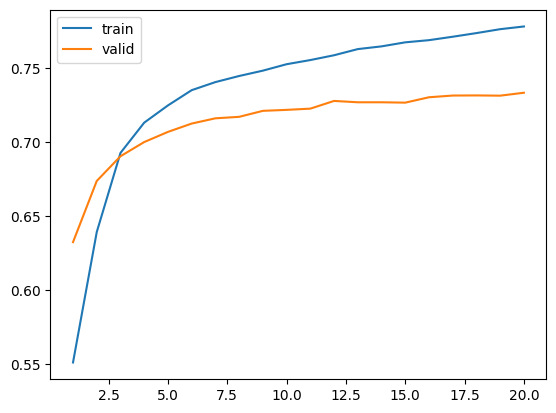

In [21]:
import matplotlib.pyplot as plt
import seaborn as sns

# Entrenamiento
epoch_count = range(1, len(hist.history['accuracy']) + 1)
sns.lineplot(x=epoch_count,  y=hist.history['accuracy'], label='train')
sns.lineplot(x=epoch_count,  y=hist.history['val_accuracy'], label='valid')
plt.show()

### 5 - Inferencia
Experimentar el funcionamiento de su modelo. Recuerde que debe realizar la inferencia de los modelos por separado de encoder y decoder.

In [22]:
def reply_to_sentence(input_seq):
    # Obtenemos del encoder los estados h y c de la secuencia de entrada
    states_value = encoder_model.predict(input_seq, verbose=0)

    # Se inicializa la secuencia de entrada al decoder como "<sos>"
    target_seq = np.zeros((1, 1))
    target_seq[0, 0] = word2idx_outputs['<sos>']

    # Se obtiene el índice que finaliza la inferencia
    eos = word2idx_outputs['<eos>']

    output_sentence = []
    for _ in range(max_out_len):
        # Predicción del próximo elemento
        output_tokens, h, c = decoder_model.predict([target_seq] + states_value, verbose=0)
        idx = np.argmax(output_tokens[0, 0, :])

        # Si es "end of sentece <eos>" se acaba
        if eos == idx:
            break

        # Transformar idx a palabra
        word = ''
        if idx > 0:
            word = idx2word_target[idx]
            output_sentence.append(word)

        # Actualizar los estados dada la última predicción
        states_value = [h, c]

        # Actualizar secuencia de entrada con la salida (re-alimentación)
        target_seq[0, 0] = idx

    return ' '.join(output_sentence)

#### Probando con una frase aleatoria del set de entrenamiento

In [31]:
rng = np.random.default_rng(seed=1234)
i = rng.choice(len(input_sentences))
input_seq = encoder_input_sequences[i:i+1]
respuesta = reply_to_sentence(input_seq)
print('-')
print('Entrada aleatoria:', input_sentences[i])
print('Respuesta:', respuesta)

-
Entrada aleatoria: do you like haribo 
Respuesta: i am a student


#### Probando una entrada arbitraria

In [24]:
input_test = "hi"
print('Entrada:', input_test)
integer_seq_test = input_tokenizer.texts_to_sequences([input_test])[0]
print("Representacion en vector de tokens de ids (palabras no registradas en el tokenizer no apareceran como ids):", integer_seq_test)
encoder_sequence_test = pad_sequences([integer_seq_test], maxlen=max_input_len)
print("Vector con padding al inicio:", encoder_sequence_test)

print('-'*20)

print('Entrada:', input_test)
respuesta = reply_to_sentence(encoder_sequence_test)
print('Respuesta:', respuesta)

Entrada: hi
Representacion en vector de tokens de ids (palabras no registradas en el tokenizer no apareceran como ids): [11]
Vector con padding al inicio: [[ 0  0  0  0  0  0  0  0 11]]
--------------------
Entrada: hi
Respuesta: hello how are you


#### Chatbot

In [25]:
!pip install -q gradio


[notice] A new release of pip is available: 26.0 -> 26.0.1
[notice] To update, run: pip install --upgrade pip


In [27]:
import gradio as gr

conversation_history = []

def chat(user_message):
  global conversation_history
  
  # Add user message to history
  conversation_history.append(f"You: {user_message}")
  
  # Get bot response
  integer_seq = input_tokenizer.texts_to_sequences([user_message])[0]
  encoder_sequence = pad_sequences([integer_seq], maxlen=max_input_len)
  bot_response = reply_to_sentence(encoder_sequence)
  
  # Add bot response to history
  conversation_history.append(f"  Bot: {bot_response}")
  
  # Format conversation for display
  formatted_conversation = "\n".join(conversation_history)
  
  return formatted_conversation, ""

# Create Gradio interface
with gr.Blocks() as demo:
  gr.Markdown("# Chatbot QA")
  
  conversation_display = gr.Textbox(
    label="Conversation",
    interactive=False,
    lines=8
  )
  
  user_input = gr.Textbox(
    label="Your message",
    placeholder="Type your message here..."
  )
  
  send_button = gr.Button("Send")
  
  user_input.submit(
    chat,
    inputs=user_input,
    outputs=[conversation_display, user_input]
  )
  
  send_button.click(
    chat,
    inputs=user_input,
    outputs=[conversation_display, user_input]
  )

demo.launch()

* Running on local URL:  http://127.0.0.1:7861
* To create a public link, set `share=True` in `launch()`.


#### Sesión de chat de ejemplo
Para tener una sesión interactiva propia, correr la celda de arriba.

![chat_image.png](chat_image.png)

### 6 - Conclusión

Algunas frases parecen ser más faciles de responder que otras. Al probar con la entrada "hi", el Chatbot responde también saludando. Pero con otro tipo de entradas se confunde muy facilmente. Ejemplo:

Entrada: do you like haribo
Respuesta: i am a student

Teniendo en cuenta que hay más saludos que otros tipos de interacciones, esto sugiere que lo que hace falta es una cantidad mayor de datos para mejorar las capacidades de respuesta del bot.

Lo que salta a la vista es que cada frase que genera el bot tiene coherencia en si misma, más allá de lo acertada que fuere. Para esto los pesos de glove nos dan una mano ya que contienen el entrenamiento sobre una gran cantidad de datos.